In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv(r"D:\Downloads\iris.csv")

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df = df.iloc[:,1:]

In [5]:
df.head()

,sepal_width,petal_length,petal_width,species
0,3.5,1.4,0.2,setosa
1,3.0,1.4,0.2,setosa
2,3.2,1.3,0.2,setosa
3,3.1,1.5,0.2,setosa
4,3.6,1.4,0.2,setosa


In [6]:
from sklearn.preprocessing import LabelEncoder

In [7]:
encoder = LabelEncoder()

In [8]:
df['species'] = encoder.fit_transform(df['species'])

In [9]:
df.head()

,sepal_width,petal_length,petal_width,species
0,3.5,1.4,0.2,0
1,3.0,1.4,0.2,0
2,3.2,1.3,0.2,0
3,3.1,1.5,0.2,0
4,3.6,1.4,0.2,0


In [10]:
df = df[df['species'] != 0][['sepal_width','petal_length','species']]

In [11]:
df.head()

,sepal_width,petal_length,species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [12]:
import seaborn as sns 
import matplotlib.pyplot as plt

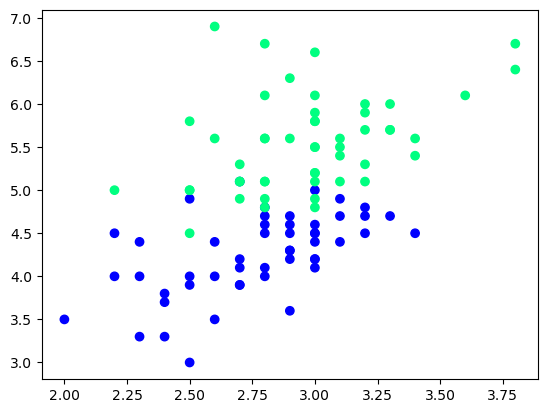

In [13]:
plt.scatter(df['sepal_width'],df['petal_length'],c=df['species'],cmap='winter')

In [16]:
df_train = df.iloc[:60,:].sample(10)
df_train

,sepal_width,petal_length,species
58,2.9,4.6,1
84,3.0,4.5,1
86,3.1,4.7,1
104,3.0,5.8,2
71,2.8,4.0,1
69,2.5,3.9,1
97,2.9,4.3,1
83,2.7,5.1,1
96,2.9,4.2,1
88,3.0,4.1,1


In [17]:
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [18]:
df_train


,sepal_width,petal_length,species
65,3.1,4.4,1
85,3.4,4.5,1
63,2.9,4.7,1
145,3.0,5.2,2
144,3.3,5.7,2
92,2.6,4.0,1
103,2.9,5.6,2
79,2.6,3.5,1
126,2.8,4.8,2
55,2.8,4.5,1


In [19]:
df_val

,sepal_width,petal_length,species
135,3.0,6.1,2
149,3.0,5.1,2
89,2.5,4.0,1
98,2.5,3.0,1
127,3.0,4.9,2


In [20]:
df_test

,sepal_width,petal_length,species
73,2.8,4.7,1
50,3.2,4.7,1
109,3.6,6.1,2
56,3.3,4.7,1
110,3.2,5.1,2


In [21]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [22]:
y_test

array([2, 2, 1, 1, 2])

***case 1 - bagging***

In [24]:
df_bag = df_train.sample(8,replace=True)
x = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]
df_bag

,sepal_width,petal_length,species
63,2.9,4.7,1
144,3.3,5.7,2
79,2.6,3.5,1
65,3.1,4.4,1
92,2.6,4.0,1
92,2.6,4.0,1
145,3.0,5.2,2
92,2.6,4.0,1


In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [28]:

dt_bag1 = DecisionTreeClassifier()

In [38]:
from sklearn.metrics import accuracy_score

# def evaluate(model, x, y):
#     y_pred = model.predict(x)
#     acc = accuracy_score(y, y_pred)
#     print("Accuracy:", acc)
def evaluate(clf,x,y):
    clf.fit(x,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(x.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(x_test)
    print(accuracy_score(y_test,y_pred))
    

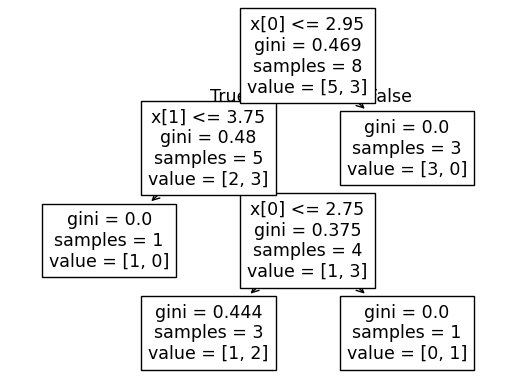

C:\Users\sumit\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


NameError: name 'x_test' is not defined

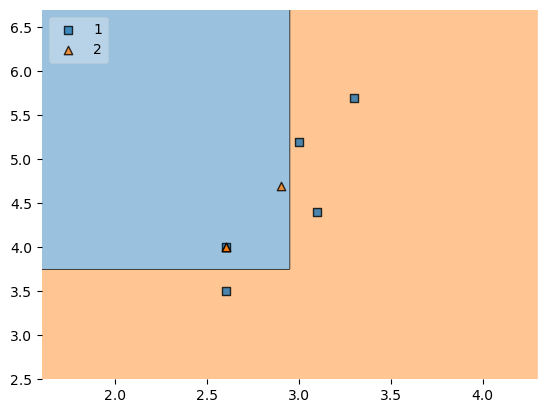

In [39]:
evaluate(dt_bag1,x,y)

In [40]:
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag


,sepal_width,petal_length,species
126,2.8,4.8,2
79,2.6,3.5,1
63,2.9,4.7,1
65,3.1,4.4,1
103,2.9,5.6,2
144,3.3,5.7,2
103,2.9,5.6,2
144,3.3,5.7,2


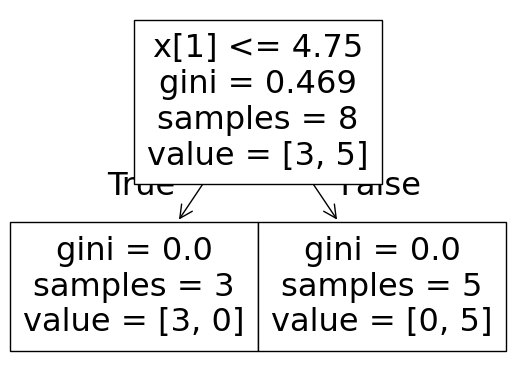

C:\Users\sumit\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


NameError: name 'x_test' is not defined

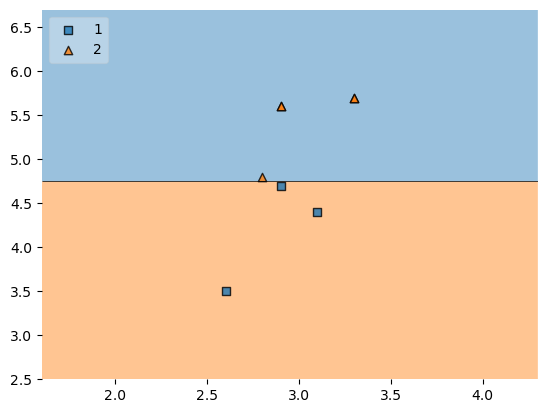

In [41]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [42]:
# predict 

In [43]:

df_test

,sepal_width,petal_length,species
73,2.8,4.7,1
50,3.2,4.7,1
109,3.6,6.1,2
56,3.3,4.7,1
110,3.2,5.1,2


In [45]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
# print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
# print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [2]


C:\Users\sumit\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [46]:
# pasting

In [47]:
# Row sampling without replacement
df_train

,sepal_width,petal_length,species
65,3.1,4.4,1
85,3.4,4.5,1
63,2.9,4.7,1
145,3.0,5.2,2
144,3.3,5.7,2
92,2.6,4.0,1
103,2.9,5.6,2
79,2.6,3.5,1
126,2.8,4.8,2
55,2.8,4.5,1


In [48]:
df_train.sample(8)

,sepal_width,petal_length,species
144,3.3,5.7,2
103,2.9,5.6,2
145,3.0,5.2,2
85,3.4,4.5,1
79,2.6,3.5,1
63,2.9,4.7,1
65,3.1,4.4,1
92,2.6,4.0,1


Random Subspaces

In [50]:
df1 = pd.read_csv(r"D:\Downloads\iris.csv")
df1 = df1.sample(10)

In [51]:
df1

,sepal_length,sepal_width,petal_length,petal_width,species
15,5.7,4.4,1.5,0.4,setosa
109,7.2,3.6,6.1,2.5,virginica
138,6.0,3.0,4.8,1.8,virginica
105,7.6,3.0,6.6,2.1,virginica
137,6.4,3.1,5.5,1.8,virginica
92,5.8,2.6,4.0,1.2,versicolor
27,5.2,3.5,1.5,0.2,setosa
59,5.2,2.7,3.9,1.4,versicolor
75,6.6,3.0,4.4,1.4,versicolor
106,4.9,2.5,4.5,1.7,virginica


In [52]:

df1.sample(2,replace=True,axis=1)

,sepal_length,petal_length
15,5.7,1.5
109,7.2,6.1
138,6.0,4.8
105,7.6,6.6
137,6.4,5.5
92,5.8,4.0
27,5.2,1.5
59,5.2,3.9
75,6.6,4.4
106,4.9,4.5



Random Patches

In [53]:

df1

,sepal_length,sepal_width,petal_length,petal_width,species
15,5.7,4.4,1.5,0.4,setosa
109,7.2,3.6,6.1,2.5,virginica
138,6.0,3.0,4.8,1.8,virginica
105,7.6,3.0,6.6,2.1,virginica
137,6.4,3.1,5.5,1.8,virginica
92,5.8,2.6,4.0,1.2,versicolor
27,5.2,3.5,1.5,0.2,setosa
59,5.2,2.7,3.9,1.4,versicolor
75,6.6,3.0,4.4,1.4,versicolor
106,4.9,2.5,4.5,1.7,virginica


In [54]:

df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,petal_length,petal_width
27,1.5,0.2
75,4.4,1.4
75,4.4,1.4
92,4.0,1.2
59,3.9,1.4
105,6.6,2.1
105,6.6,2.1
137,5.5,1.8
